# 🏥 Diabetes Prediction using Machine Learning

## Objective
To build a machine learning model that predicts whether a person is diabetic or not based on medical attributes.

## Problem Type
Binary Classification (0 = Non-Diabetic, 1 = Diabetic)

## Techniques Used
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Scaling
- Machine Learning Models
- Model Evaluation

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

We import essential libraries:
- pandas → data handling
- numpy → numerical operations
- matplotlib & seaborn → data visualization

In [2]:
df = pd.read_csv("C:/Users/surek/OneDrive/Desktop/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


We load the dataset using pandas and display first 5 rows to understand structure.

In [3]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


We analyze dataset structure:
- shape → rows & columns
- info → data types & null values
- describe → statistical summary

In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#  Missing Value Analysis

We check whether the dataset contains any missing (null) values.

This is a critical step in Data Preprocessing because:
- Missing values can reduce model accuracy
- They may require imputation (mean/median filling)
- Clean datasets improve machine learning performance

---

##  Dataset Columns:

- Pregnancies → 0 missing values  
- Glucose → 0 missing values  
- BloodPressure → 0 missing values  
- SkinThickness → 0 missing values  
- Insulin → 0 missing values  
- BMI → 0 missing values  
- DiabetesPedigreeFunction → 0 missing values  
- Age → 0 missing values  
- Outcome → 0 missing values  

---

##  Final Conclusion:

✔ No missing values in the dataset  
✔ Dataset is already clean  
✔ No need for imputation  
✔ Ready for Exploratory Data Analysis (EDA) and Machine Learning

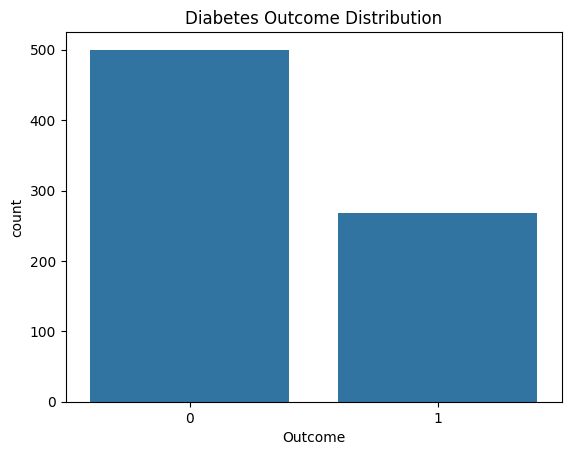

In [5]:
sns.countplot(x='Outcome', data=df)
plt.title("Diabetes Outcome Distribution")
plt.show()

Shows how many patients are diabetic vs non-diabetic.
Helps understand class imbalance.

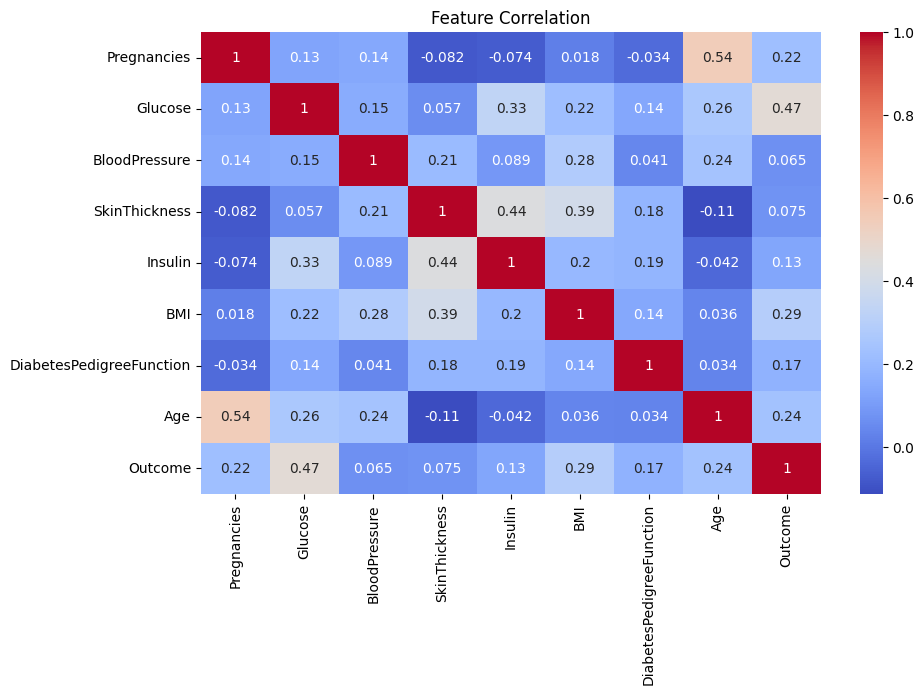

In [6]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

Shows relationship between features.
Helps identify important predictors like Glucose and BMI.

In [7]:
cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in cols:
    df[col] = df[col].replace(0, np.nan)

df.fillna(df.mean(), inplace=True)

In medical datasets, 0 values are invalid.
We replace them with NaN and then fill with mean values.

In [8]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (614, 8)
X_test shape: (154, 8)
y_train shape: (614,)
y_test shape: (154,)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [12]:
y_pred = rf.predict(X_test)

print(y_pred[:10])

[0 0 0 0 0 1 0 1 1 1]


In [13]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7532467532467533


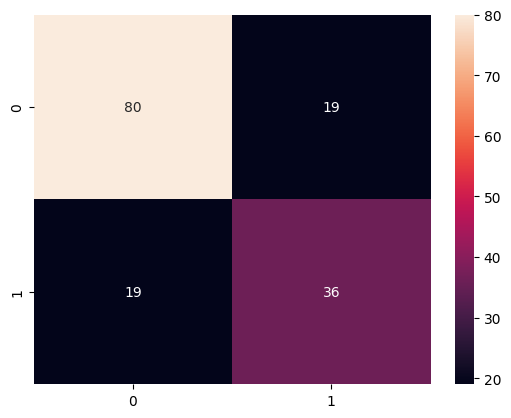

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [16]:
input_data = (5,120,70,20,79,25.0,0.5,33)

input_array = np.asarray(input_data).reshape(1,-1)

prediction = rf.predict(input_array)

if prediction[0] == 1:
    print("High Risk of Diabetes")
else:
    print("No Diabetes Risk")
    

No Diabetes Risk


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

Glucose                     0.257437
BMI                         0.166827
Age                         0.131211
DiabetesPedigreeFunction    0.118966
Insulin                     0.093984
BloodPressure               0.084190
SkinThickness               0.073973
Pregnancies                 0.073412
dtype: float64


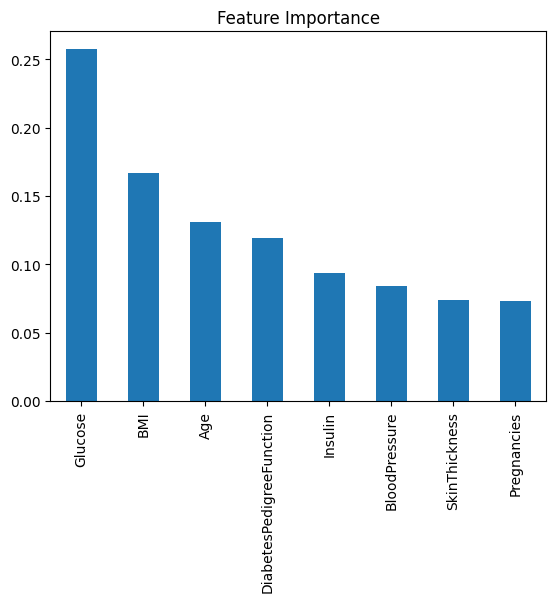

In [18]:
feature_importance.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

In [19]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.8304866850321395


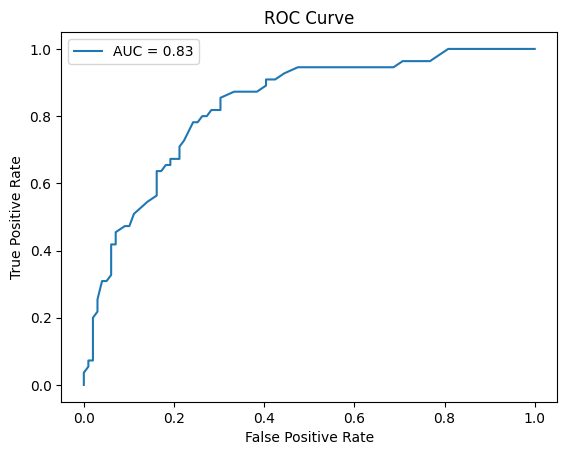

In [20]:
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

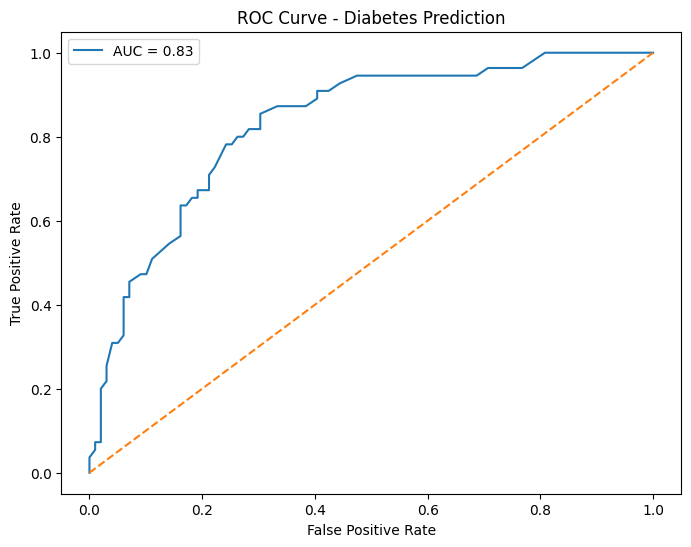

In [22]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Diabetes Prediction")

plt.legend()

plt.show()

In [23]:
from sklearn.metrics import confusion_matrix, classification_report

In [25]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[82 17]
 [21 34]]


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154



In [29]:
model.predict(X_test)

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

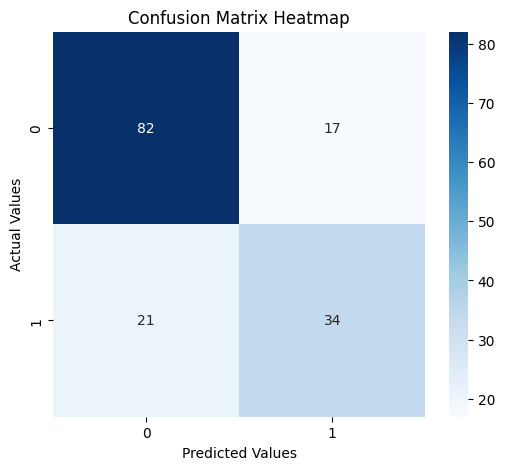

In [30]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted Values")

plt.ylabel("Actual Values")

plt.title("Confusion Matrix Heatmap")

plt.show()

In [31]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.7532467532467533


In [32]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_score)

ROC-AUC Score: 0.8242424242424242


In [33]:
import pickle

pickle.dump(model, open("diabetes_model.pkl", "wb"))

In [34]:
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [35]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import streamlit as st
import pickle
import numpy as np

# Load model and scaler
model = pickle.load(open('diabetes_model.pkl', 'rb'))
scaler = pickle.load(open('scaler.pkl', 'rb'))

# Page config
st.set_page_config(
    page_title="Diabetes Prediction System",
    page_icon="🩺",
    layout="centered"
)

# Custom CSS
st.markdown("""
<style>
.main {
    background-color: #f5f7fa;
}

.stButton>button {
    background-color: #2563eb;
    color: white;
    border-radius: 10px;
    height: 3em;
    width: 100%;
    font-size: 18px;
}

.result-box {
    padding: 20px;
    border-radius: 10px;
    font-size: 22px;
    font-weight: bold;
    text-align: center;
}
</style>
""", unsafe_allow_html=True)

# Sidebar
st.sidebar.title("🩺 Diabetes ML App")

st.sidebar.info(
    """
    This AI system predicts whether a person is diabetic or not
    using Machine Learning.
    """
)

# Main Title
st.title("🩺 Diabetes Prediction System")

st.write("Enter patient health details below:")

# Input fields
pregnancies = st.number_input("Pregnancies", min_value=0.0)

glucose = st.number_input("Glucose Level", min_value=0.0)

blood_pressure = st.number_input("Blood Pressure", min_value=0.0)

skin_thickness = st.number_input("Skin Thickness", min_value=0.0)

insulin = st.number_input("Insulin Level", min_value=0.0)

bmi = st.number_input("BMI", min_value=0.0)

dpf = st.number_input("Diabetes Pedigree Function", min_value=0.0)

age = st.number_input("Age", min_value=0.0)

# Prediction button
if st.button("Predict Diabetes"):

    input_data = np.array([[pregnancies,
                            glucose,
                            blood_pressure,
                            skin_thickness,
                            insulin,
                            bmi,
                            dpf,
                            age]])

    # Scale data
    std_data = scaler.transform(input_data)

    # Prediction
    prediction = model.predict(std_data)

    # Output
    if prediction[0] == 0:

        st.success("✅ The person is NOT diabetic")

    else:

        st.error("⚠ The person is diabetic")

        st.warning(
            """
            Recommendation:
            • Maintain healthy diet
            • Exercise regularly
            • Monitor glucose levels
            • Consult a healthcare professional
            """
        )

# Footer
st.markdown("---")
st.caption("Built using Machine Learning, Python & Streamlit")